In [16]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack, selection)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut, load_for_stack

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

# Reading in output and stacking

In [18]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.5            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 90             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 55.0
bg_outer_arcsec = 65.0

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 1000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg_prod = replace(cfg,
                   field=field,
                   bin_mode=bin_mode,
                   bins=bins,
                   mask_method=mask_method,
                   bg_inner_arcsec=bg_inner_arcsec,
                   bg_outer_arcsec=bg_outer_arcsec,
                   rest_wave_min=rest_wave_min,
                   rest_wave_max=rest_wave_max,
                   n_bootstrap=n_bootstrap,
                   #flux_unit='flux_arcsec2',
                   #rest_density=False,
                   line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg_prod.cut_radial_bin, cfg_prod.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
mega = multicat.combine_products(products, label_col="SUBSET")

# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg_prod, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks = stack.build_stacks(cfg_prod, mega, keep_cube=True)

print(f"BOTH:   {mega.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

Finite-spectrum cut (bin 9, > 100 px): kept 227 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 275 / 278 galaxies
combined 2 products -> 502 galaxies (origin in column 'SUBSET')


BOTH:   502 galaxies
AEGIS:  227 galaxies
COSMOS: 275 galaxies


# Galaxy SN Search

In [19]:
# load your core (per-galaxy) product
prod_egs_core = core.read_core_fits("outputs_core/7-5-26-core_extraction_egs_MF.fits")
prod_cosmos_core = core.read_core_fits("outputs_core/7-5-26-core_extraction_cosmos_MF.fits")
prod_core = stack.concat_core_prods(prod_egs_core, prod_cosmos_core)

In [83]:
# rank galaxies by Lya-window S/N, keep the top 20 successful measurements
# -> prints a ranked table: rank, row, ID, S/N, flux, label, z
sel = selection.top_sn_galaxies(prod_cosmos_core, n=50)

      rank         row          ID        SN_B        flux       label           z
         1         163       21492       132.7    8.36e+01         LAE       2.472
         2         208        6743       130.4    6.30e+01         LAE       2.487
         3         164       21598        54.3    3.34e+01         LAE       2.479
         4          32       12015        46.4    2.96e+01         LAE       2.097
         5         257       11559        39.1    1.75e+01         LAE       3.038
         6          41       11223        38.3    2.58e+01     emitter       2.103
         7          46       12104        37.6    1.77e+01     emitter       2.161
         8          58        1823        35.2    2.17e+01         LAE       3.077
         9         111       23593        29.6    1.44e+01         LAE       3.257
        10           5        5791        27.2    1.26e+01         LAE       2.435
        11         261        1870        24.4    1.17e+01         LAE       2.975
    

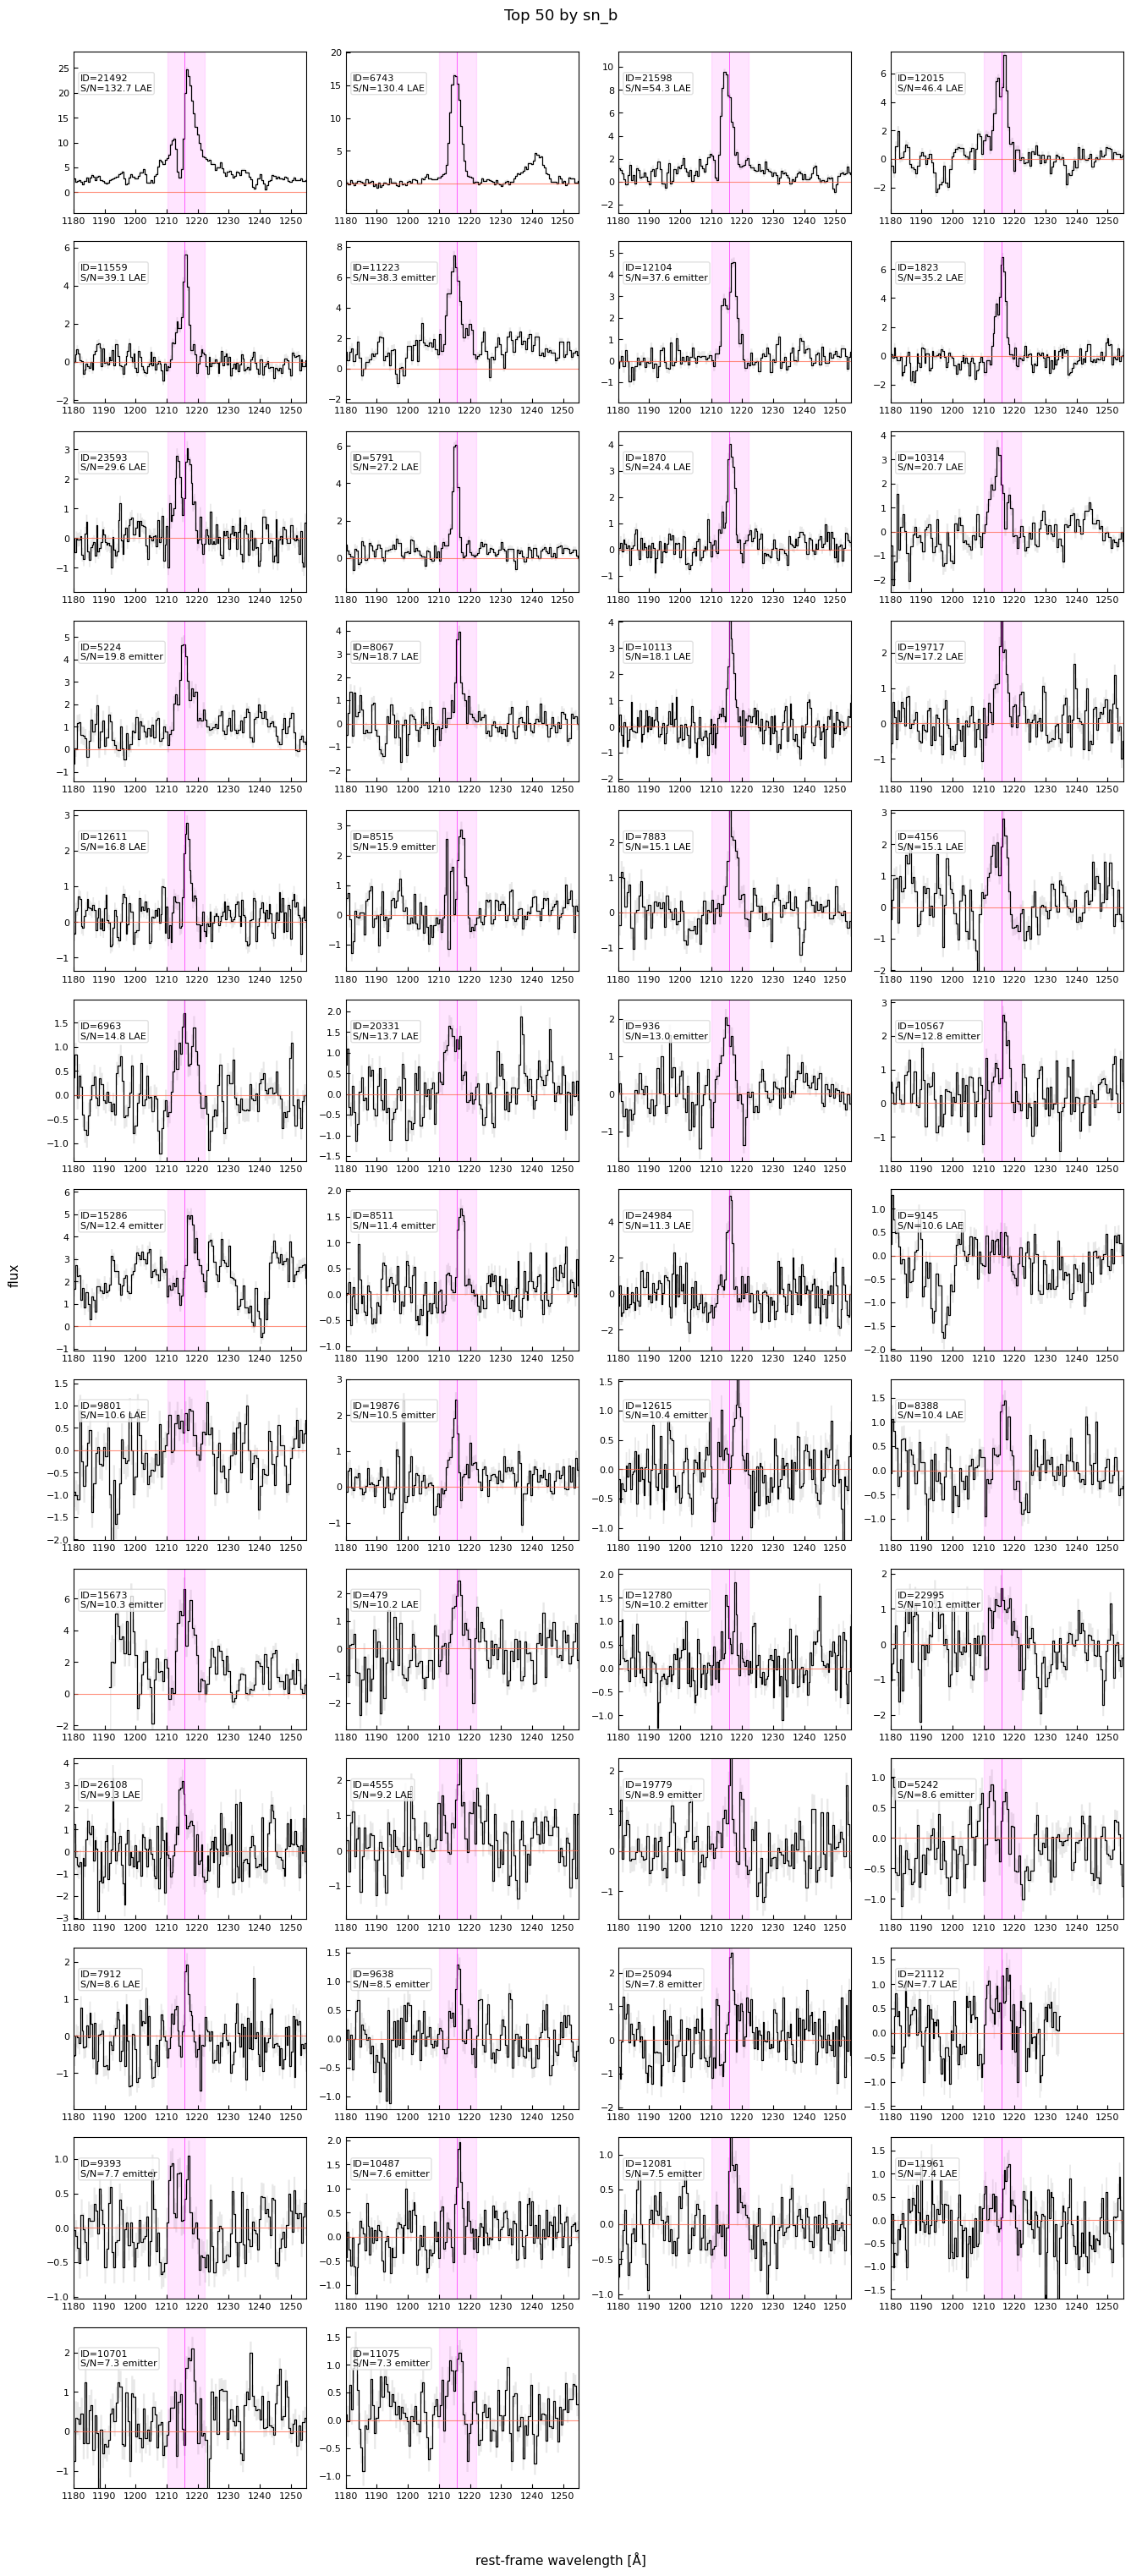

[21492, 6743, 21598, 12015, 11559, 11223, 12104, 1823, 23593, 5791, 1870, 10314, 5224, 8067, 10113, 19717, 12611, 8515, 7883, 4156, 6963, 20331, 936, 10567, 15286, 8511, 24984, 9145, 9801, 19876, 12615, 8388, 15673, 479, 12780, 22995, 26108, 4555, 19779, 5242, 7912, 9638, 25094, 21112, 9393, 10487, 12081, 11961, 10701, 11075]


In [84]:
# eyeball their spectra in a grid to decide which look promising
plotting.plot_top_sn_grid(sel, ncols=4, rest_frame=True)

# pull just the IDs you like (say the first 5 in the ranked grid) to hand off
ids_sn = selection.id_list(sel)
print(ids_sn)

# Single Galaxy

In [69]:
sg = stack.single_galaxy_spectra(cfg_prod, mega,
    gid=6963, 
    id_col='ID',
    merge_bins=[[0], [1], [2], [3], [4], [5], [6, 7], [8, 9]])

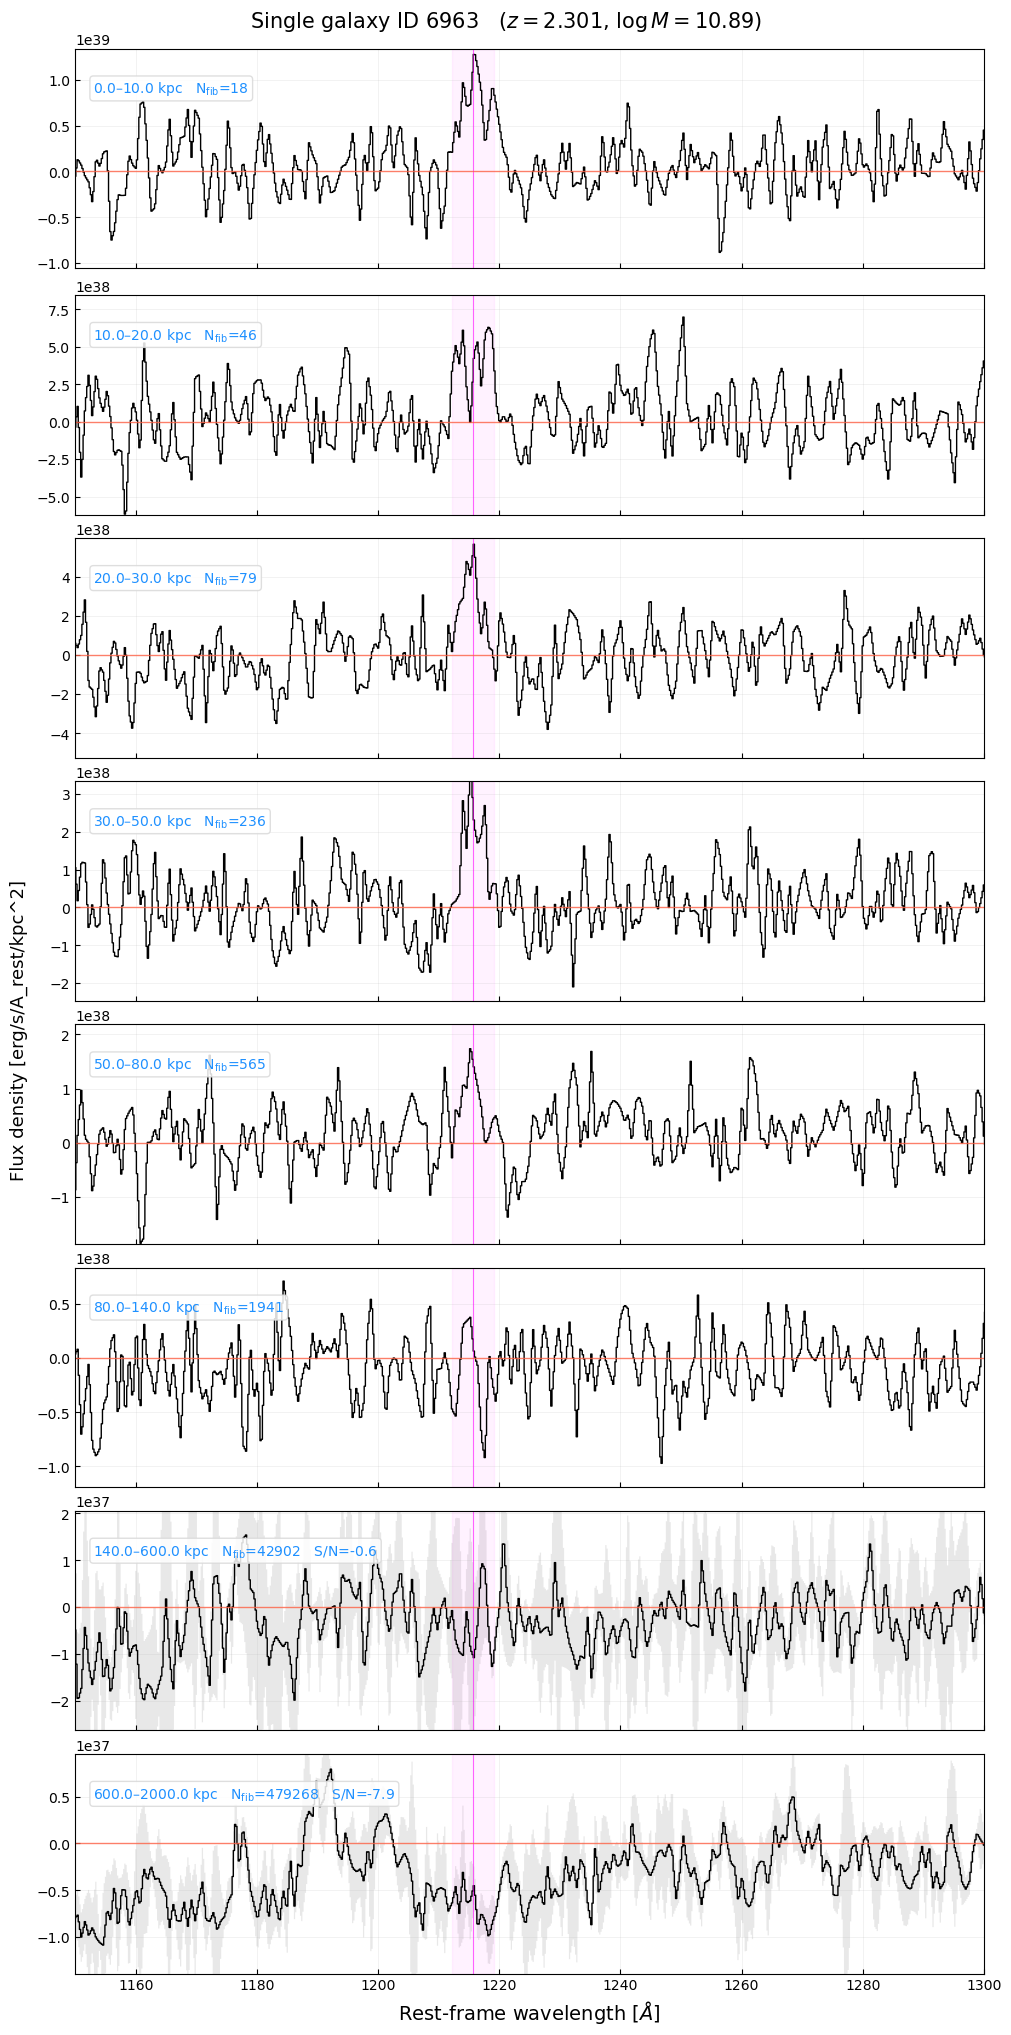

(<Figure size 1000x2000 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>],
       dtype=object))

In [70]:
plotting.plot_single_galaxy_panels(sg,
    xlim=(1150, 1300),            
    lya_window=half_width,
    figsize_width=10, 
    panel_height=2.5,
    smooth=None, 
    title=None, 
    savepath=None,
    dpi=300)

In [57]:
m_single = measure.measure_single_galaxy(sg, method="flux_median")

In [56]:
print(m_single["r_edges"], m_single["centroid_v"], m_single["sn"])

[   0.   10.   20.   30.   50.   80.  140.  600. 2000.] [          nan           nan           nan           nan           nan
           nan  600.07219753 -462.62242772] [        nan         nan         nan         nan         nan         nan
 -3.66293308 -3.64705614]


# Multi-Galaxy Stack

In [79]:
# rank galaxies by Lya-window S/N, keep the top 20 successful measurements
# -> prints a ranked table: rank, row, ID, S/N, flux, label, z
sel_top = selection.top_sn_galaxies(prod_core, n=200)
ids_top = selection.id_list(sel_top)

      rank         row          ID        SN_B        flux       label           z
         1         202       32856       178.9    5.80e+01         LAE       2.269
         2          41       17632       178.3    6.80e+01     emitter       2.300
         3         407       21492       132.7    8.36e+01         LAE       2.472
         4         452        6743       130.4    6.30e+01         LAE       2.487
         5           5        9501        70.6    3.35e+01         LAE       2.158
         6         408       21598        54.3    3.34e+01         LAE       2.479
         7         276       12015        46.4    2.96e+01         LAE       2.097
         8         501       11559        39.1    1.75e+01         LAE       3.038
         9         285       11223        38.3    2.58e+01     emitter       2.103
        10          55       34874        38.2    1.25e+01         LAE       2.291
        11         192       10873        37.7    1.21e+01         LAE       3.242
    

In [80]:
mini = multicat.stack_id_list(cfg, mega, ids_top)          # prints "matched N/M IDs"; raises/warns on misses

stack_id_list: matched 202/200 requested IDs


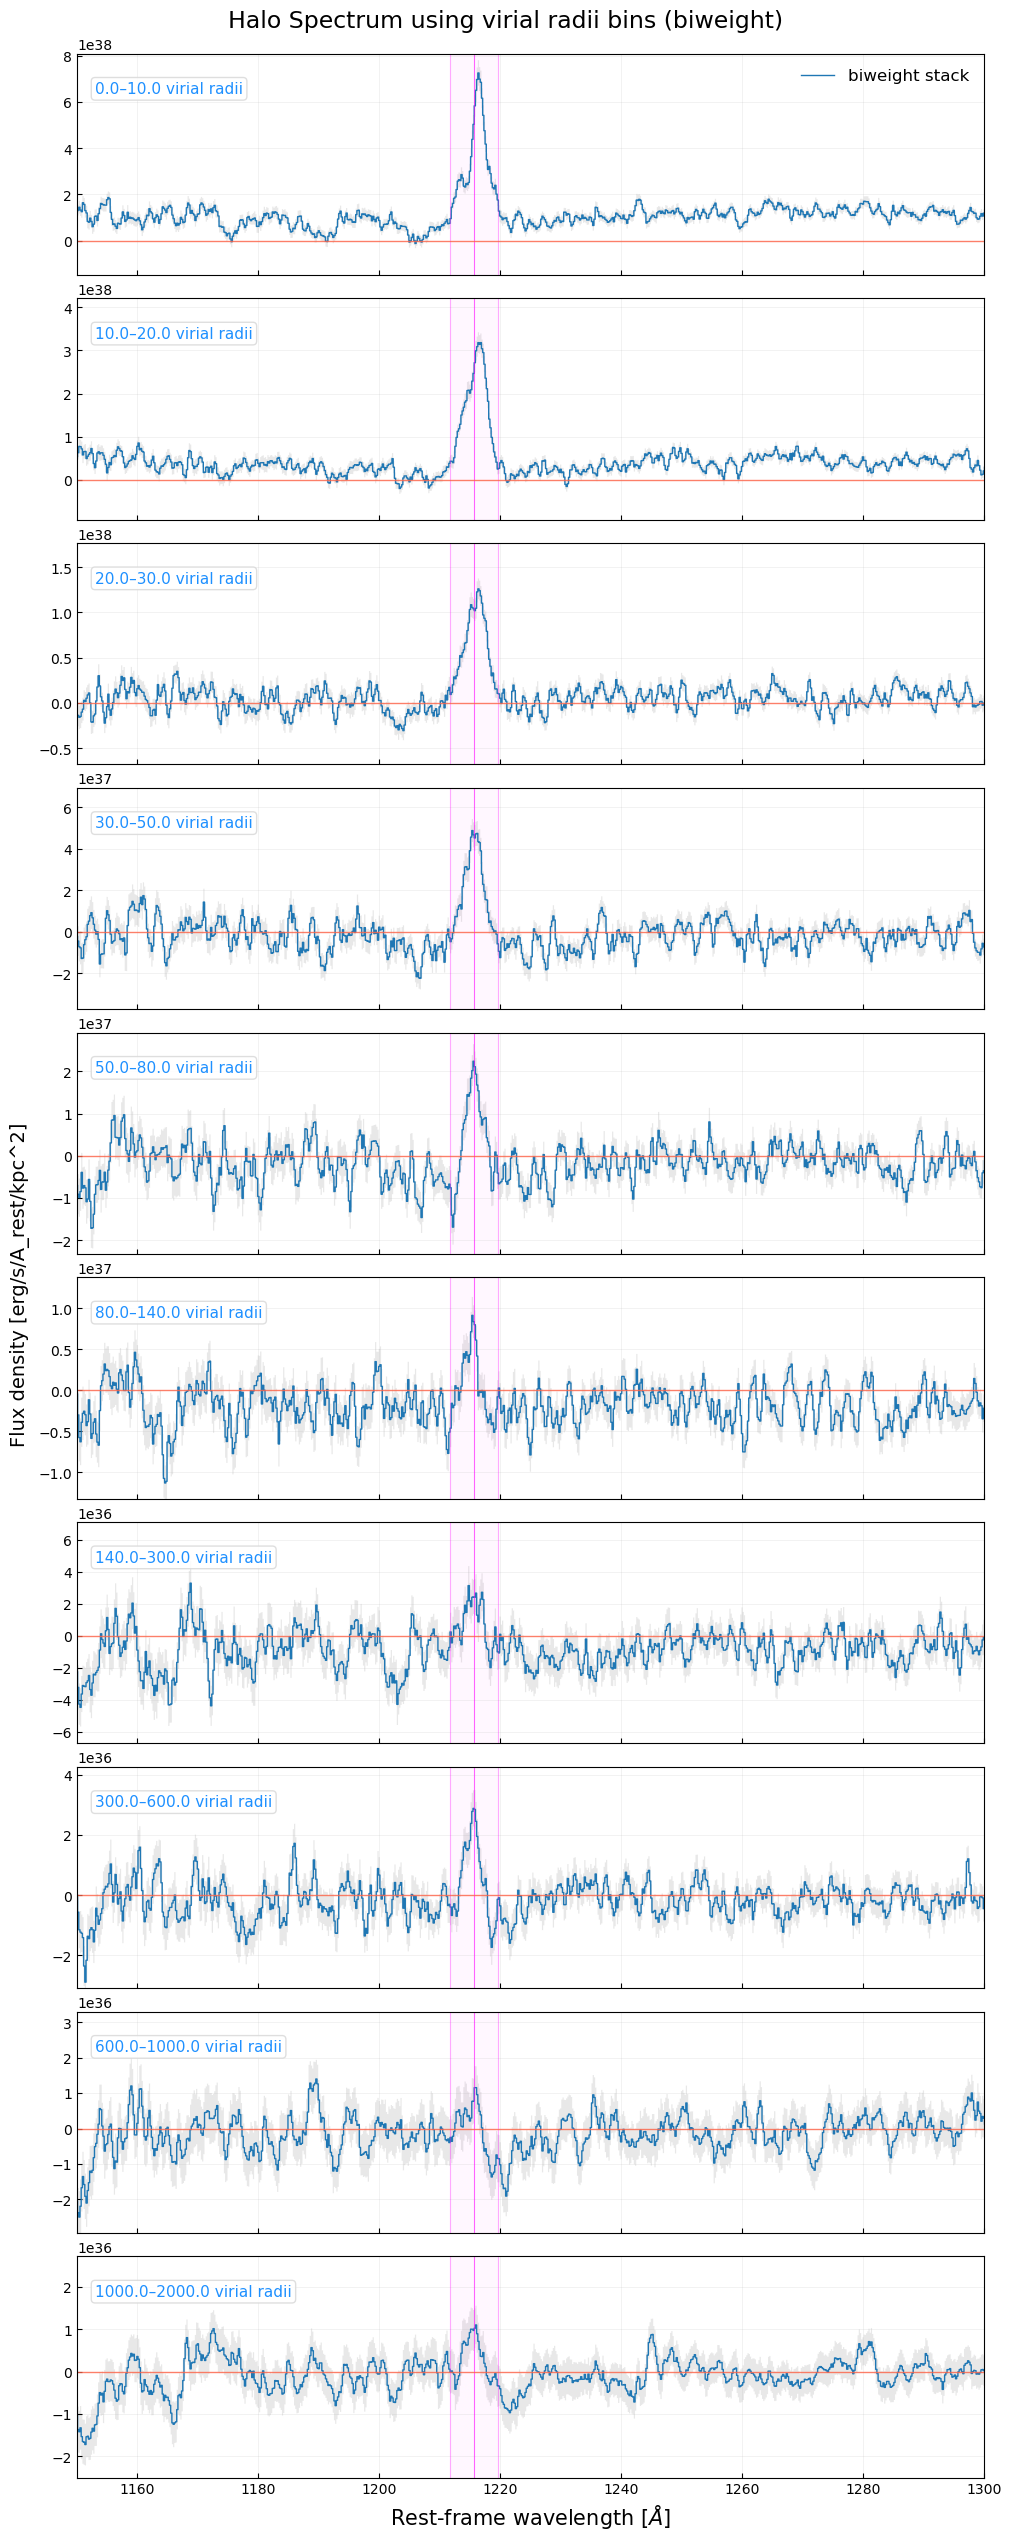

(<Figure size 1000x2500 with 10 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [82]:
plotting.plot_stack_panels(mini, method="biweight")             # radial panels for this mini-sample